# Imports

In [6]:
import numpy as np
import pandas as pd
import GEOparse
import os
import matplotlib.pyplot as plt

## Download data

In [ ]:
path=r'C:\Users\johan\Documents\Documents\School\EDA_course'
gds = GEOparse.get_GEO(geo="GDS4296", destdir=path)  # downloads SOFT automatically

df=gds.table.copy()
df

26-Jan-2026 00:16:11 DEBUG utils - Directory C:\Users\johan\Documents\Documents\School\EDA_course already exists. Skipping.
26-Jan-2026 00:16:11 INFO GEOparse - File already exist: using local version.
26-Jan-2026 00:16:11 INFO GEOparse - Parsing C:\Users\johan\Documents\Documents\School\EDA_course\GDS4296.soft.gz: 
26-Jan-2026 00:16:11 DEBUG GEOparse - DATABASE: Geo
26-Jan-2026 00:16:11 DEBUG GEOparse - DATASET: GDS4296
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_1
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_2
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_3
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_4
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_5
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_6
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_7
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_8
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_9
26-Jan-2026 00:16:11 DEBUG GEOparse - SUBSET: GDS4296_10
26-Jan-2026 00

,ID_REF,IDENTIFIER,GSM803615,GSM803674,GSM803733,GSM803616,GSM803675,GSM803734,GSM803617,GSM803676,...,GSM803785,GSM803671,GSM803729,GSM803786,GSM803672,GSM803730,GSM803787,GSM803673,GSM803731,GSM803788
0,1007_s_at,MIR4640,7.98588,6.60953,7.28692,6.81414,7.17116,7.22437,8.30001,7.97986,...,8.76158,8.87174,9.05203,9.02302,7.90743,7.85594,6.90531,10.79900,10.80540,10.95990
1,1053_at,RFC2,8.91259,8.95833,8.78347,8.68783,8.47835,8.87411,8.48144,8.44854,...,9.01109,7.99229,7.89066,7.78652,7.38044,7.94416,8.20352,7.82165,7.71562,7.79544
2,117_at,HSPA6,5.95818,5.95520,4.75223,4.96283,5.01497,4.78948,4.66964,4.70403,...,5.32821,5.22383,5.24615,4.89699,5.56850,4.93727,5.18978,5.01333,4.98273,4.97768
3,121_at,PAX8,7.25647,7.34984,7.03978,7.23067,7.63878,7.45663,7.60143,7.56602,...,7.44675,7.36011,7.30075,7.23286,7.37110,7.40892,7.23629,7.29430,7.27620,7.45836
4,1255_g_at,GUCA1A,2.70294,2.72227,2.66169,2.79379,2.97056,2.62163,3.09889,2.87228,...,2.91059,2.67582,2.74977,2.68969,2.85014,2.79400,2.74596,2.74609,2.75365,2.57236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54670,AFFX-ThrX-5_at,--Control,3.36355,3.38203,3.27553,3.14986,3.89064,3.60483,3.57585,3.47273,...,3.63189,3.52134,3.27097,3.48170,3.57577,3.39203,3.50607,3.32972,3.72726,3.35781
54671,AFFX-ThrX-M_at,--Control,2.67324,2.88409,2.64535,3.16415,3.00442,2.94171,2.83615,2.59861,...,2.88973,2.83209,2.97157,2.86661,2.73873,2.76082,2.92629,2.77477,2.84010,2.75316
54672,AFFX-TrpnX-3_at,--Control,2.72860,2.70408,2.74768,2.78068,2.72479,2.89248,2.62671,2.75595,...,2.69827,2.81731,2.71912,2.71317,2.64936,2.65647,2.55743,2.66296,2.61881,2.57263
54673,AFFX-TrpnX-5_at,--Control,3.29524,3.29139,3.21011,3.22221,3.40582,3.35663,3.12848,3.14628,...,3.16915,3.19798,3.00831,3.11467,3.31270,3.24652,3.10825,3.20608,3.14939,3.03342


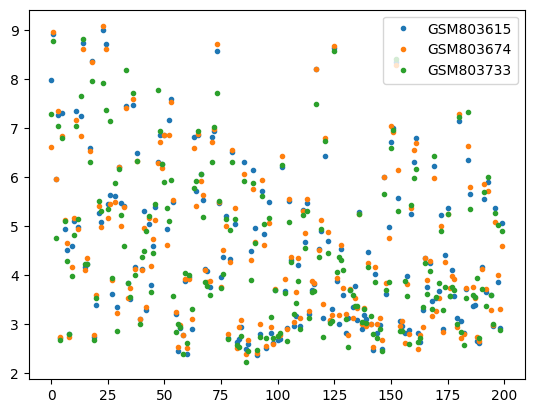

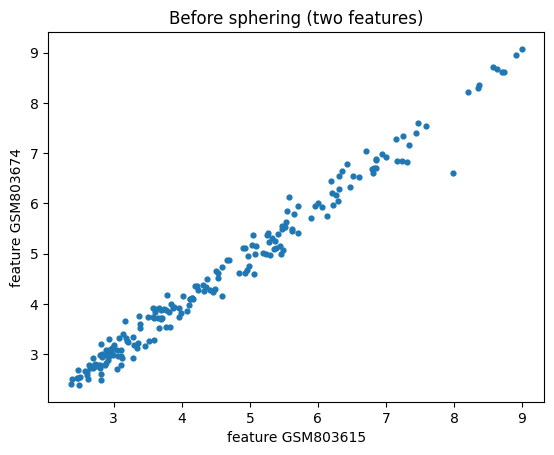

In [53]:
df_slice_200=df[0:200]
df_slice_200 
plt.plot(df_slice_200['GSM803615'].index, df_slice_200['GSM803615'],'.' , label='GSM803615')
plt.plot(df_slice_200['GSM803674'].index, df_slice_200['GSM803674'],'.', label='GSM803674')
plt.plot(df_slice_200['GSM803615'].index, df_slice_200['GSM803733'],'.', label='GSM803733')
plt.legend()
plt.show()
plt.scatter(df_slice_200['GSM803615'],df_slice_200['GSM803674'],s=12)
plt.title("Before sphering (two features)")
plt.xlabel(f"feature {'GSM803615'}")
plt.ylabel(f"feature {'GSM803674'}")
plt.show()



## sphering

diag (first 5): [1. 1. 1. 1. 1.]
max off-diag abs: 6.648138706211171e-10


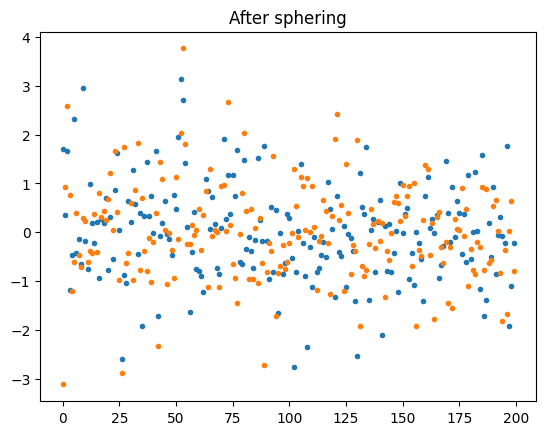

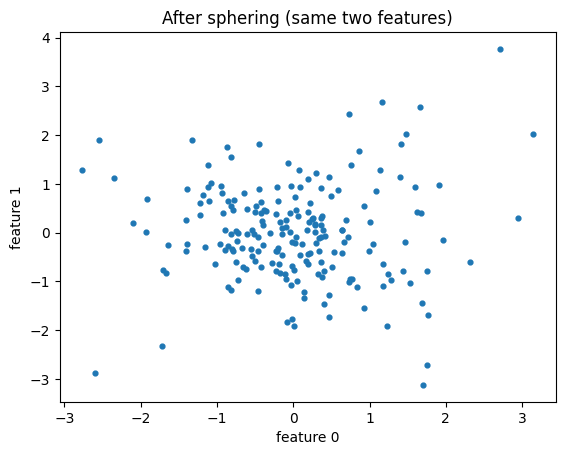

In [56]:
df_200_genes= df_slice_200.drop(['ID_REF', 'IDENTIFIER'], axis=1)
df_200_genes
means=df_200_genes.mean()
df_c=df_200_genes-means
df_cov=df_c.cov()
eigvals, eigvecs = np.linalg.eigh(df_cov)
#
eps = 1e-12 #epsilon to avoid when eigenvalues are 0or extremly small
Lambda_inv_sqrt = np.diag(1.0 / np.sqrt(eigvals + eps)) # greate a diagonal of eigenvalues 1/square(eighvals+e)

W = eigvecs @ Lambda_inv_sqrt @ eigvecs.T   # sphering transform (ZCA)
Z = df_c @ W 
covZ = np.cov(Z, rowvar=False)
print("diag (first 5):", np.diag(covZ)[:5])
print("max off-diag abs:", np.max(np.abs(covZ - np.eye(covZ.shape[0]))))


plt.plot(Z[0].index, Z[0], '.')
plt.plot(Z[1].index, Z[1], '.')
plt.title('After sphering')
plt.show()
plt.scatter(Z[0], Z[1],s=12)
plt.title("After sphering (same two features)")
plt.xlabel(f"feature {0}")
plt.ylabel(f"feature {1}")
plt.show()

Most correlated feature pair: 15 16 corr= 0.9945132637203355


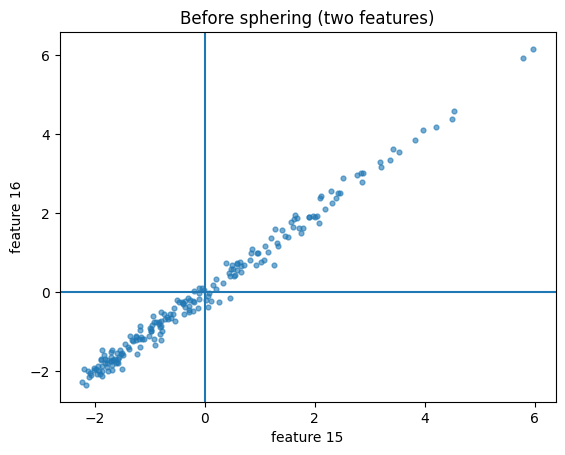

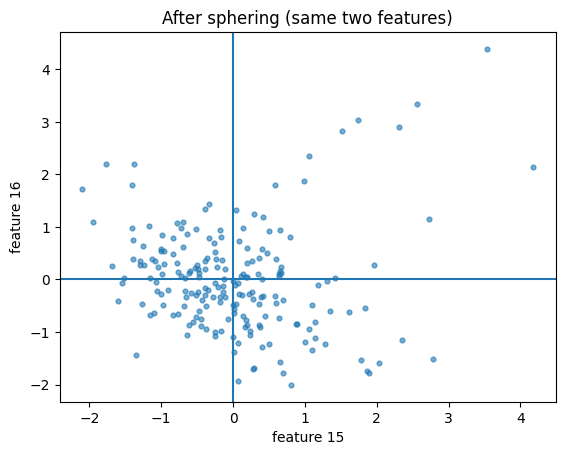

In [50]:
Xc_np = df_c.to_numpy()
Z_np  = Z if isinstance(Z, np.ndarray) else Z.to_numpy()

# correlation between features (genes)
R = np.corrcoef(Xc_np, rowvar=False)
np.fill_diagonal(R, 0)

i, j = np.unravel_index(np.argmax(np.abs(R)), R.shape)
print("Most correlated feature pair:", i, j, "corr=", R[i, j])

plt.figure()
plt.scatter(Xc_np[:, i], Xc_np[:, j], s=12, alpha=0.6)
plt.title("Before sphering (two features)")
plt.xlabel(f"feature {i}")
plt.ylabel(f"feature {j}")
plt.axhline(0); plt.axvline(0)
plt.show()

plt.figure()
plt.scatter(Z_np[:, i], Z_np[:, j], s=12, alpha=0.6)
plt.title("After sphering (same two features)")
plt.xlabel(f"feature {i}")
plt.ylabel(f"feature {j}")
plt.axhline(0); plt.axvline(0)
plt.show()

In [ ]:
n=Z.shape[1]
cos_similarity=np.zeros((n,n))
cos_similarity
for i in range(n):
    for j in range(n):
        xi = Z[i]
        xj = Z[j]
        cos_similarity[i, j] = np.dot(xi, xj) / ((np.linalg.norm(xi) ) * (np.linalg.norm(xj) ))